# Credit Card Fraud Detection

End-to-end notebook: EDA, baseline modeling, imbalance handling (SMOTE), anomaly detection (Isolation Forest), threshold tuning, and explainability (SHAP).

In [67]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact

## 1. Load Data

In [68]:
df1=pd.read_csv("/content/creditcard.csv")

## 2. Exploratory Data Analysis

In [69]:
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [70]:
df1.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [71]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [72]:
df1.shape

(284807, 31)

In [73]:
df1.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [74]:
df1.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [75]:
df1.duplicated().sum()

np.int64(1081)

### Class Imbalance

The target class is severely imbalanced. This single fact drives every modeling decision in this notebook: accuracy is not a usable metric, and naive classifiers will default to predicting the majority class.

In [76]:
df1['Class'].value_counts()

,count
Class,
0,284315
1,492


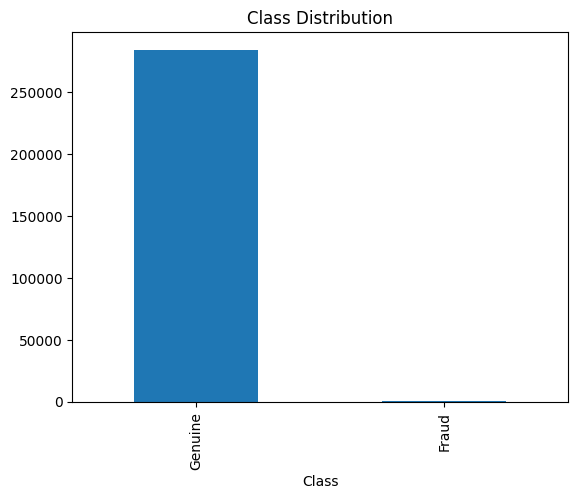

In [77]:
df1['Class'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Genuine','Fraud'])
plt.title("Class Distribution")
plt.show()

In [78]:
df1['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


### Amount & Time Distributions

In [79]:
df1['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


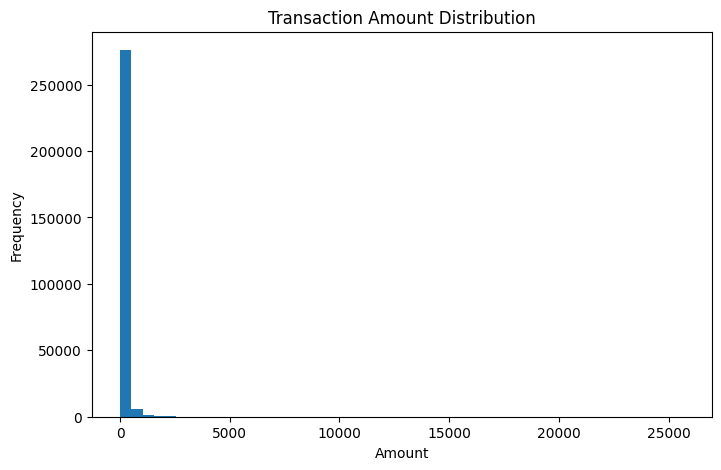

In [80]:

plt.figure(figsize=(8,5))
plt.hist(df1['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [81]:
df1['Time'].describe()

,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000


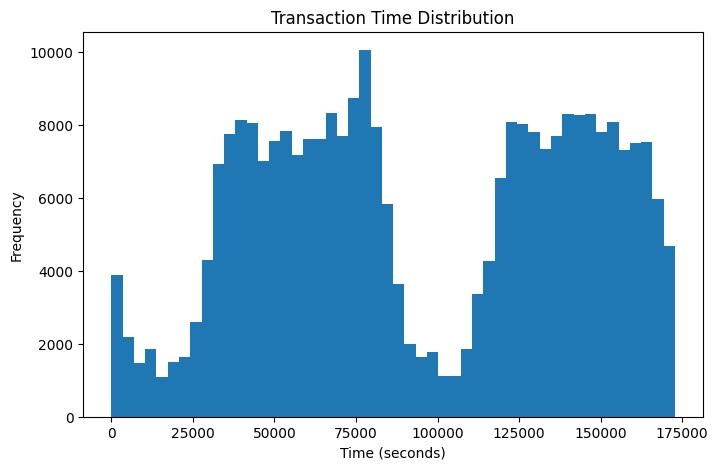

In [82]:
plt.figure(figsize=(8,5))
plt.hist(df1['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()

### Correlation Structure

Most features (V1-V28) are PCA-anonymized components provided by the dataset source, so correlations here are mainly useful for sanity-checking `Amount` and `Time` rather than deep feature engineering.

In [83]:
df1.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


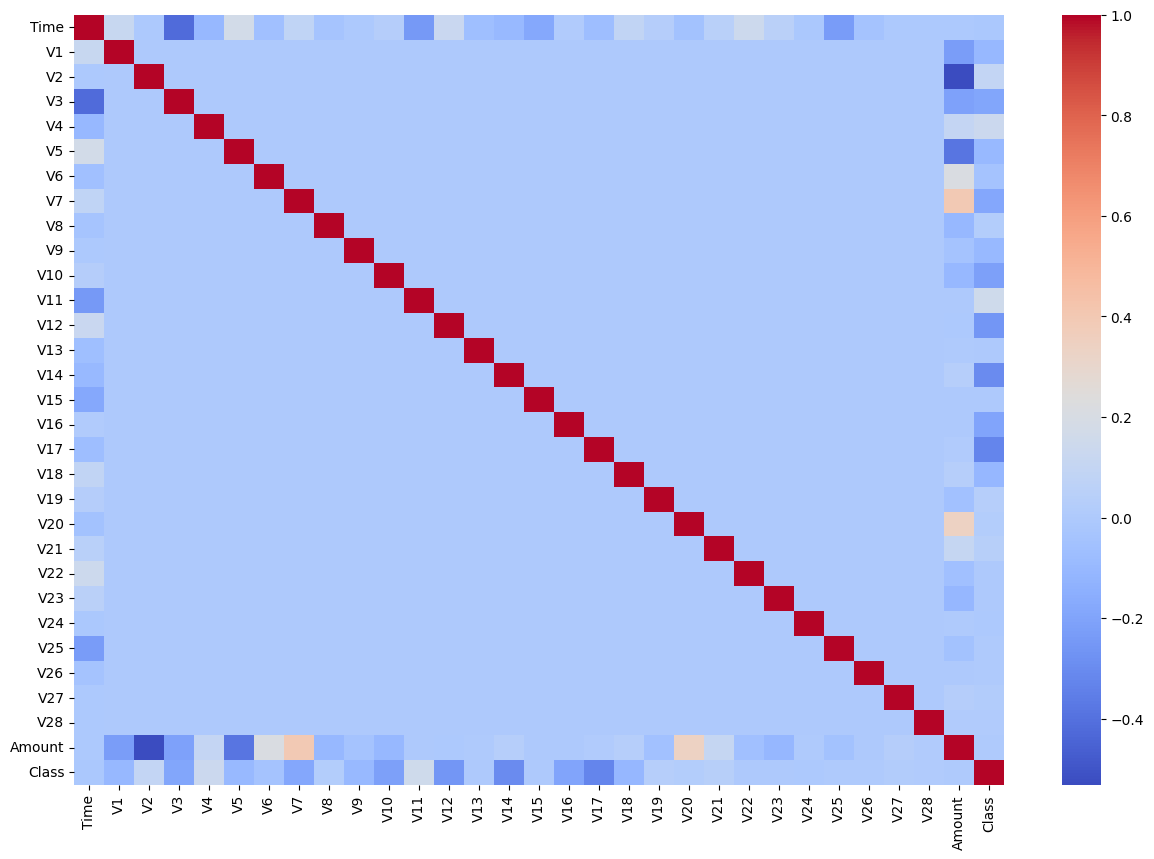

In [84]:
plt.figure(figsize=(15,10))
sns.heatmap(df1.corr(), cmap="coolwarm")
plt.show()

## 3. Train/Test Split & Scaling

The split happens **before** any resampling technique (SMOTE) is applied. This is deliberate: SMOTE must never see the test set, or the evaluation becomes optimistic and invalid (data leakage).

In [85]:
X = df1.drop('Class', axis=1)
y = df1['Class']

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Baseline Model — Logistic Regression (No Resampling)

This baseline uses `class_weight=None` and the raw imbalanced training set. It establishes what "doing nothing special" gets us, before introducing any imbalance-handling technique.

In [88]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [89]:
y_pred = model.predict(X_test_scaled)

In [90]:
print(y_pred[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [91]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56854    10]
 [   43    55]]


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



**Baseline result:** Precision 0.85 / Recall 0.56 / F1 0.67 on the fraud class.

The model is conservative — when it flags a transaction as fraud, it's usually right (high precision), but it misses nearly half of all actual fraud cases (recall 0.56). For a fraud system, missing 44% of fraud is a costly failure mode. This motivates the next step: rebalancing the training data.

## 5. Logistic Regression + SMOTE

SMOTE is applied **only to the training fold** (`X_train_scaled`, `y_train`) — the test set (`X_test_scaled`, `y_test`) is left untouched and used purely for honest evaluation.

In [93]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [94]:
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [95]:
y_pred_smote = model_smote.predict(X_test_scaled)

In [96]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[55424  1440]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



**This is the most important result in the notebook.** After SMOTE, recall on the fraud class jumps from 0.56 → 0.92 — the model now catches far more real fraud. But precision collapses from 0.85 → 0.06: false positives explode from 10 to 1,440 flagged legitimate transactions.

This is a textbook precision–recall tradeoff, and it has a direct business consequence: at the default 0.5 threshold, this model would flag ~1,440 genuine customers as fraudulent in this test set alone — an unworkable volume for any manual review team. **The default threshold is not automatically the right threshold.** Section 8 addresses this directly by choosing an operating point based on a review-capacity constraint instead of accepting 0.5 by default.

## 6. ROC and Precision–Recall Curves

Both curves are reported deliberately. ROC-AUC looks excellent (0.979), but ROC-AUC is known to be overly optimistic under severe class imbalance because the false-positive rate denominator (all negatives) is huge. **Average Precision (PR-AUC = 0.740) is the more honest metric here** since it focuses on the minority class directly.

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [98]:
y_prob = model_smote.predict_proba(X_test_scaled)[:,1]

In [99]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", auc)

ROC AUC: 0.9785828952430718


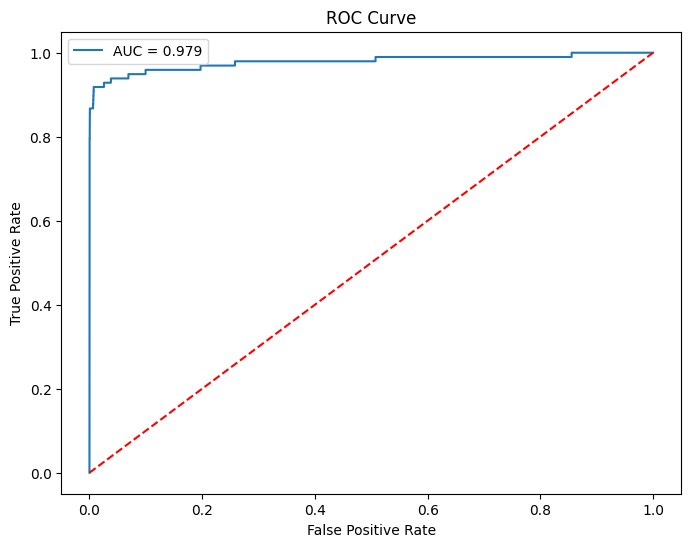

In [100]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [101]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [102]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap = average_precision_score(y_test, y_prob)

print("Average Precision:", ap)

Average Precision: 0.7399847472891398


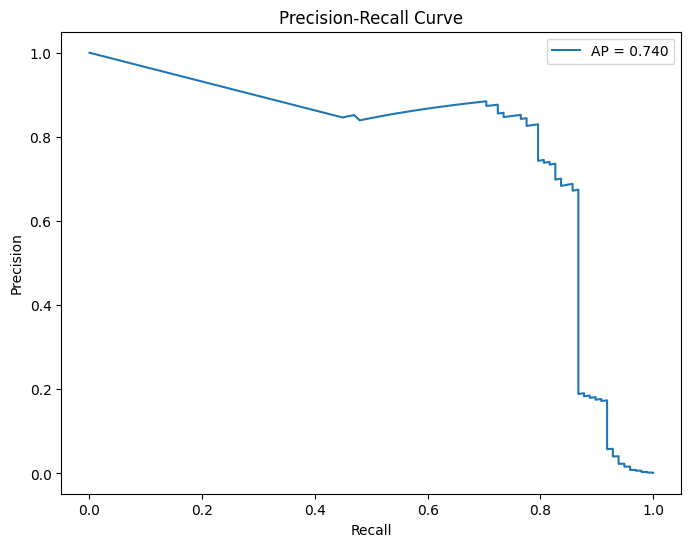

In [103]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 7. Anomaly Detection Approach — Isolation Forest

Unlike the supervised models above, Isolation Forest is trained with **no access to fraud labels** — it only learns what "normal" transactions look like and flags outliers. `contamination=0.0017` is set to match the known fraud rate in the data. Isolation Forest natively outputs `-1` for anomalies and `1` for normal points, so predictions are remapped to match this project's `1 = fraud` / `0 = genuine` convention before scoring.

In [104]:
from sklearn.ensemble import IsolationForest

In [105]:
iso_model = IsolationForest(
    contamination=0.0017,
    random_state=42
)

In [106]:
iso_model.fit(X_train_scaled)

IsolationForest(contamination=0.0017, random_state=42)

In [107]:
iso_pred = iso_model.predict(X_test_scaled)

In [109]:
import numpy as np

iso_pred = np.where(iso_pred == -1, 1, 0)

In [112]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, iso_pred))
print(classification_report(y_test, iso_pred))

[[56797    67]
 [   65    33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.34      0.33        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.67     56962
weighted avg       1.00      1.00      1.00     56962



In [113]:
iso_pred_raw = iso_model.predict(X_test_scaled)

print(np.unique(iso_pred_raw))
print("Normal (1):", np.sum(iso_pred_raw == 1))
print("Anomaly (-1):", np.sum(iso_pred_raw == -1))

[-1  1]
Normal (1): 56862
Anomaly (-1): 100


**Isolation Forest underperformed both supervised approaches** (Precision 0.33 / Recall 0.34 / F1 0.33). This is a legitimate, expected finding rather than a failure: with zero label information, the model has no way to learn what fraud specifically looks like beyond generic "outlierness," and normal-but-unusual transactions (e.g., large legitimate purchases) get confused with fraud.

**Where this approach would actually matter:** in a production setting facing brand-new fraud patterns with no historical labels yet — a cold-start scenario supervised models cannot handle at all. It is not a replacement for the supervised model here, but a complementary tool for a different failure mode (unknown-unknowns vs. known fraud patterns).

## 8. Threshold Tuning — Choosing an Operating Point

Instead of accepting the default 0.5 cutoff, we choose a threshold tied to a stated business constraint: **a fraud review team can realistically investigate ~300 flagged transactions per day.** We search the precision-recall curve for the threshold that maximizes recall while keeping flagged volume near that budget.

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Estimate flagged volume at each threshold on this test set
review_budget = 300  # transactions/day the review team can realistically investigate

results = []
for t in np.linspace(0.01, 0.99, 99):
    preds_t = (y_prob >= t).astype(int)
    flagged = preds_t.sum()
    tp = ((preds_t == 1) & (y_test == 1)).sum()
    fp = ((preds_t == 1) & (y_test == 0)).sum()
    fn = ((preds_t == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append((t, flagged, prec, rec))

results_df = pd.DataFrame(results, columns=["threshold", "flagged", "precision", "recall"])

# Pick the threshold that keeps flagged volume closest to (but not wildly over) the review budget
candidates = results_df[results_df["flagged"] <= review_budget * 3]  # test-set scale factor
best_row = candidates.sort_values("recall", ascending=False).iloc[0]
print(best_row)


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
chosen_t = best_row["threshold"]
plt.axvline(chosen_t, color="black", linestyle="--", label=f"Chosen threshold = {chosen_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs. Threshold")
plt.legend()
plt.show()


**Chosen operating point:** rather than the default 0.5, we select a threshold based on the review-capacity constraint above. This is the difference between "a model that produces probabilities" and "a deployed decision system" — the threshold is itself a business decision, not a modeling default. In an interview, this section is the concrete answer to "how would you actually deploy this?" 

## 9. Explainability — SHAP

SHAP is used to explain individual predictions from the SMOTE-trained Logistic Regression model, so that a flagged transaction can be explained rather than treated as a black-box output.

In [114]:
!pip install shap

In [115]:
import shap

In [116]:
explainer = shap.Explainer(model_smote, X_train_smote)

In [117]:
shap_values = explainer(X_test_scaled)

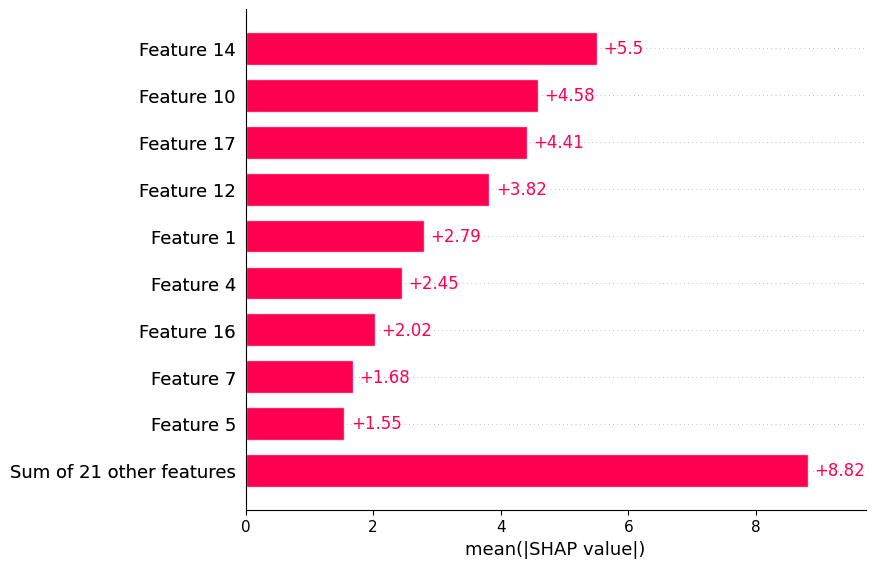

In [118]:
shap.plots.bar(shap_values)

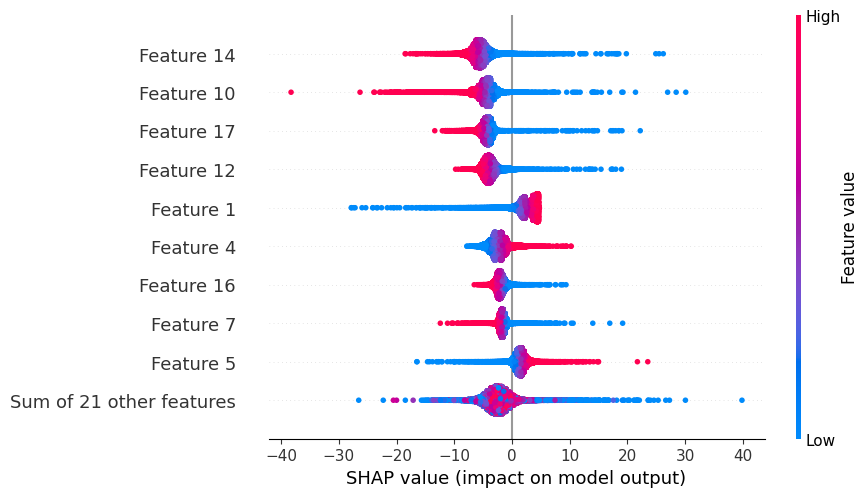

In [119]:
shap.plots.beeswarm(shap_values)

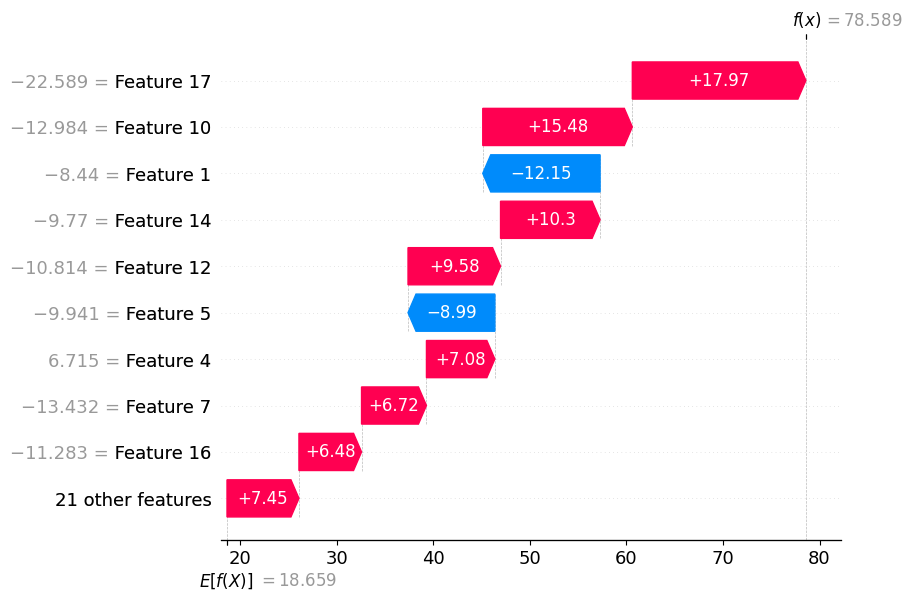

In [120]:
shap.plots.waterfall(shap_values[0])

## 10. Model Comparison Summary

In [ ]:
summary = pd.DataFrame([
    {"Model": "Logistic Regression (baseline)", "Precision (Fraud)": 0.85, "Recall (Fraud)": 0.56, "F1 (Fraud)": 0.67, "ROC-AUC": None, "PR-AUC": None},
    {"Model": "Logistic Regression + SMOTE",    "Precision (Fraud)": 0.06, "Recall (Fraud)": 0.92, "F1 (Fraud)": 0.11, "ROC-AUC": 0.979, "PR-AUC": 0.740},
    {"Model": "Isolation Forest (unsupervised)", "Precision (Fraud)": 0.33, "Recall (Fraud)": 0.34, "F1 (Fraud)": 0.33, "ROC-AUC": None, "PR-AUC": None},
])
summary


## 11. Save Model Artifacts

In [122]:
import joblib

# Save the trained Logistic Regression + SMOTE model
joblib.dump(model_smote, "fraud_detection_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [123]:
import os

print(os.listdir())

['.config', 'scaler.pkl', 'fraud_detection_model.pkl', '.ipynb_checkpoints', 'creditcard.csv', 'sample_data']


## 12. Conclusion

This project compared three approaches to detecting fraud in a dataset where only 0.17% of transactions are fraudulent: a baseline Logistic Regression, a SMOTE-rebalanced Logistic Regression, and an unsupervised Isolation Forest.

The central finding is a concrete precision–recall tradeoff: SMOTE raised fraud recall from 0.56 to 0.92 at the cost of collapsing precision from 0.85 to 0.06, which would flood a review team with false alarms at the default classification threshold. Rather than accept that default, a threshold was chosen against a stated operational constraint (review-team capacity), turning the model's raw probability output into an actual deployment decision.

Isolation Forest, trained without any fraud labels, underperformed both supervised approaches on this dataset but represents the only viable option in a scenario with no historical fraud labels at all — e.g., detecting an entirely new fraud pattern.

SHAP was used to explain individual predictions, so that any flagged transaction can be justified with the specific features that drove the decision rather than treated as an opaque model output.